# 05 Model XGBoost - Rolling Backtest 24h (Monthly Refit)

Monthly full refit at month boundaries, daily 24h forecasts, and Jan-Feb focus option for fast target-period evaluation.


In [1]:
# If needed:
# %pip install xgboost scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
# Config
DATA_PATH = '../../data_cleaned/merged/02_4_clean_data.csv'
TARGET = 'price'
H = 24
VAL_DAYS = 14

# Monthly refit controls
RETRAIN_MONTHLY = True
FOCUS_JAN_FEB_ONLY = True
MAX_CYCLES = None

start_date = pd.Timestamp('2019-01-01 00:00:00')
split_date = pd.Timestamp('2025-01-01 00:00:00')
end_date = pd.Timestamp('2026-01-01 00:00:00')


In [3]:
# Load and prepare data
df = pd.read_csv(DATA_PATH)

df['period_start_utc'] = pd.to_datetime(df['period_start_utc'], errors='coerce', utc=True).dt.tz_localize(None)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df = df[(df['date'] >= start_date) & (df['date'] < end_date)].copy()
df = pd.get_dummies(df, columns=['year'], drop_first=True)

df = df.rename(columns={'period_start_utc': 'ds', TARGET: 'y'})
df = df.sort_values('ds').reset_index(drop=True)

print(f'Rows: {len(df):,}')
print(f'Range: {df.ds.min()} -> {df.ds.max()}')


Rows: 61,367
Range: 2019-01-01 00:00:00 -> 2025-12-31 22:00:00


In [4]:
# Feature set aligned with current project decision
base_features = [
    'load_forecast_da', 'res_sum_da', 'gen_forecast_da',
    'dayofyear_sin1', 'dayofyear_cos1',
    'hour_sin1', 'hour_cos1',
    'dayofweek_sin1', 'dayofweek_cos1',
    'is_holiday', 'price_gas'
]
year_dummies = [c for c in df.columns if c.startswith('year_')]
FEATURES = base_features + year_dummies

required = FEATURES + ['ds', 'y']
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

model_df = df[['ds', 'y'] + FEATURES].copy()

print(f'Number of features: {len(FEATURES)}')
print(FEATURES)


Number of features: 17
['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday', 'price_gas', 'year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2024', 'year_2025']


In [5]:
# Rolling daily cutoffs
cutoffs = pd.date_range(start=split_date, end=end_date - pd.Timedelta(days=1), freq='D')
if FOCUS_JAN_FEB_ONLY:
    cutoffs = [c for c in cutoffs if c < pd.Timestamp('2025-03-01')]
if MAX_CYCLES is not None:
    cutoffs = cutoffs[:MAX_CYCLES]
print(f'Forecast cycles: {len(cutoffs)} days')


Forecast cycles: 59 days


In [6]:
# Helper to train one daily model without test leakage
def fit_one_model(train_hist: pd.DataFrame, features: list, val_days: int = 14) -> XGBRegressor:
    val_hours = 24 * val_days
    if len(train_hist) <= val_hours + 24:
        raise ValueError('Not enough history for train/validation split.')

    subtrain = train_hist.iloc[:-val_hours]
    val = train_hist.iloc[-val_hours:]

    model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=100
    )

    model.fit(
        subtrain[features], subtrain['y'],
        eval_set=[(val[features], val['y'])],
        verbose=False
    )
    return model


In [7]:
# Rolling daily backtest loop with monthly full refit
pred_rows = []
model = None
current_month = None

for i, cutoff in enumerate(cutoffs, 1):
    train_hist = model_df[model_df['ds'] < cutoff]
    horizon_end = cutoff + pd.Timedelta(hours=H)
    test_h = model_df[(model_df['ds'] >= cutoff) & (model_df['ds'] < horizon_end)].copy()

    if len(test_h) != H:
        continue

    cutoff_month = pd.Timestamp(cutoff).to_period('M')
    if (model is None) or (RETRAIN_MONTHLY and cutoff_month != current_month):
        model = fit_one_model(train_hist=train_hist, features=FEATURES, val_days=VAL_DAYS)
        current_month = cutoff_month

    test_h['prediction'] = model.predict(test_h[FEATURES])
    test_h['cutoff'] = cutoff
    pred_rows.append(test_h[['cutoff', 'ds', 'y', 'prediction']])

    if i % 10 == 0:
        print(f'Processed {i}/{len(cutoffs)} cycles')

results = pd.concat(pred_rows, ignore_index=True)
results = results.rename(columns={'y': 'actual'})
results.head()


Processed 10/59 cycles
Processed 20/59 cycles
Processed 30/59 cycles
Processed 40/59 cycles
Processed 50/59 cycles


,cutoff,ds,actual,prediction
0,2025-01-01,2025-01-01 00:00:00,1.60,12.173888
1,2025-01-01,2025-01-01 01:00:00,0.00,11.308557
2,2025-01-01,2025-01-01 02:00:00,-0.01,13.508547
3,2025-01-01,2025-01-01 03:00:00,-0.01,13.161062
4,2025-01-01,2025-01-01 04:00:00,-0.06,12.642077


In [8]:
# Point-forecast metrics
rmse = mean_squared_error(results['actual'], results['prediction'], squared=False)
mae = mean_absolute_error(results['actual'], results['prediction'])
eps = 1e-8
mape = np.mean(np.abs((results['actual'] - results['prediction']) / np.maximum(np.abs(results['actual']), eps))) * 100

print(f'RMSE: {rmse:,.4f}')
print(f'MAE:  {mae:,.4f}')
print(f'MAPE: {mape:,.2f}%')


RMSE: 24.5356
MAE:  15.0175
MAPE: 79,863,214.39%


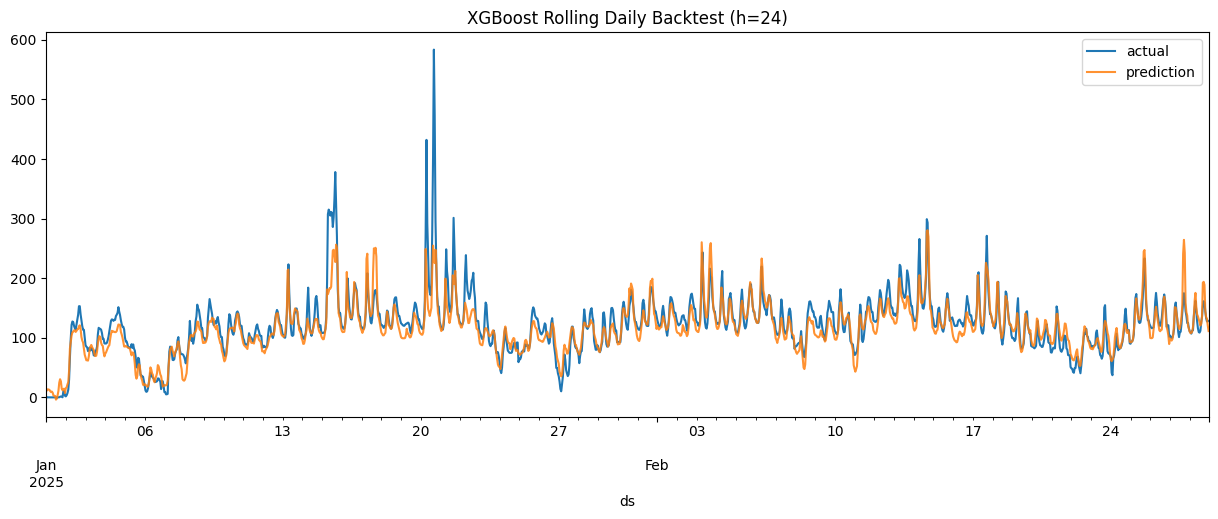

In [9]:
# Plot complete 2025 test period
plot_df = results.set_index('ds').sort_index()
ax = plot_df[['actual']].plot(figsize=(15, 5), title='XGBoost Rolling Daily Backtest (h=24)')
plot_df['prediction'].plot(ax=ax, alpha=0.85)
ax.legend(['actual', 'prediction'])
plt.show()


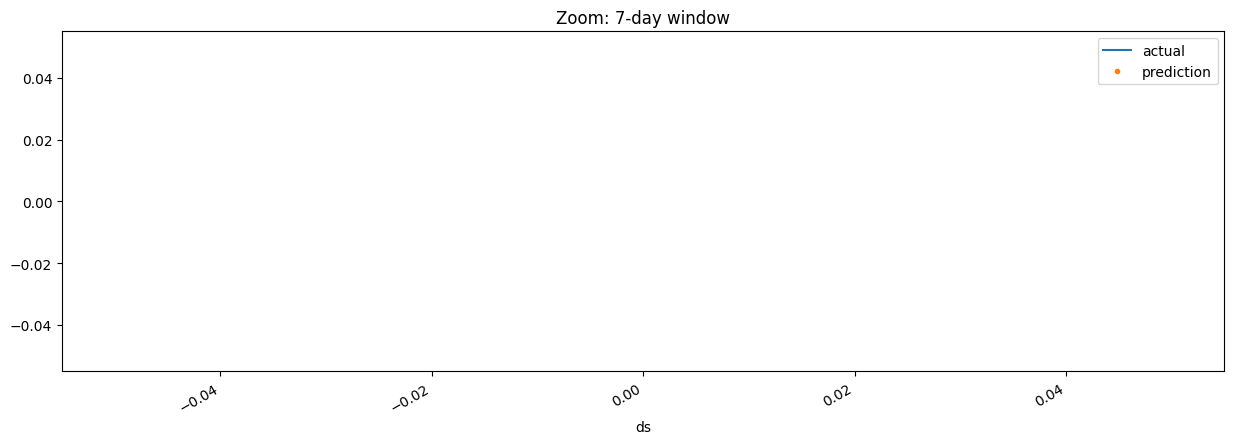

In [10]:
# Zoom: one week example
zoom_start = split_date + pd.Timedelta(days=90)
zoom_end = zoom_start + pd.Timedelta(days=7)
zoom = plot_df[(plot_df.index >= zoom_start) & (plot_df.index < zoom_end)]

ax = zoom[['actual']].plot(figsize=(15, 5), title='Zoom: 7-day window')
zoom['prediction'].plot(ax=ax, style='.')
ax.legend(['actual', 'prediction'])
plt.show()


## Optional Next Step
If runtime is too high, reduce `n_estimators` or retrain less frequently (for example every 2-3 days) while still forecasting daily horizons.

In [11]:
# Unified metrics + export for comparison
from pathlib import Path

# normalize evaluation frame name
if 'results' in locals():
    eval_df = results.copy()
elif 'res' in locals():
    eval_df = res.copy()
else:
    raise ValueError('No results dataframe found (expected `results` or `res`).')

# normalize column names
if 'y' in eval_df.columns and 'actual' not in eval_df.columns:
    eval_df = eval_df.rename(columns={'y': 'actual'})
if 'xgb' in eval_df.columns and 'prediction' not in eval_df.columns:
    eval_df = eval_df.rename(columns={'xgb': 'prediction'})
if 'ds' not in eval_df.columns and eval_df.index.name is not None:
    eval_df = eval_df.reset_index()

required_cols = {'actual', 'prediction'}
missing = required_cols - set(eval_df.columns)
if missing:
    raise ValueError(f'Missing required columns for metrics/export: {missing}')

# robust metrics for power prices (can be near zero/negative)
rmse = mean_squared_error(eval_df['actual'], eval_df['prediction'], squared=False)
mae = mean_absolute_error(eval_df['actual'], eval_df['prediction'])
smape = 100 * np.mean(
    2 * np.abs(eval_df['actual'] - eval_df['prediction']) /
    (np.abs(eval_df['actual']) + np.abs(eval_df['prediction']) + 1e-8)
)

mask = np.abs(eval_df['actual']) >= 10
mape_filtered = (
    np.mean(
        np.abs((eval_df.loc[mask, 'actual'] - eval_df.loc[mask, 'prediction']) /
               np.abs(eval_df.loc[mask, 'actual']))
    ) * 100
    if mask.any() else np.nan
)

print(f'RMSE: {rmse:,.4f}')
print(f'MAE:  {mae:,.4f}')
print(f'sMAPE: {smape:,.2f}%')
print(f'MAPE (|actual|>=10): {mape_filtered:,.2f}%')

out_dir = Path('../../artifacts/model_results')
out_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    'model': 'XGBoost_retrainM',
    'rmse': rmse,
    'mae': mae,
    'smape': smape,
    'mape_filtered_abs_ge_10': mape_filtered,
    'n_predictions': len(eval_df)
}])

metrics_df.to_csv(out_dir / 'xgboost_retrainm_metrics_rolling_24h.csv', index=False)

pred_cols = [c for c in ['unique_id', 'cutoff', 'ds', 'actual', 'prediction'] if c in eval_df.columns]
eval_df[pred_cols].to_csv(out_dir / 'xgboost_retrainm_predictions_rolling_24h.csv', index=False)

metrics_df


RMSE: 24.5356
MAE:  15.0175
sMAPE: 16.07%
MAPE (|actual|>=10): 12.87%


,model,rmse,mae,smape,mape_filtered_abs_ge_10,n_predictions
0,XGBoost_retrainM,24.53558,15.017468,16.07429,12.867319,1416
